<a href="https://colab.research.google.com/github/dannynacker/SLSD/blob/main/wp1_session_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

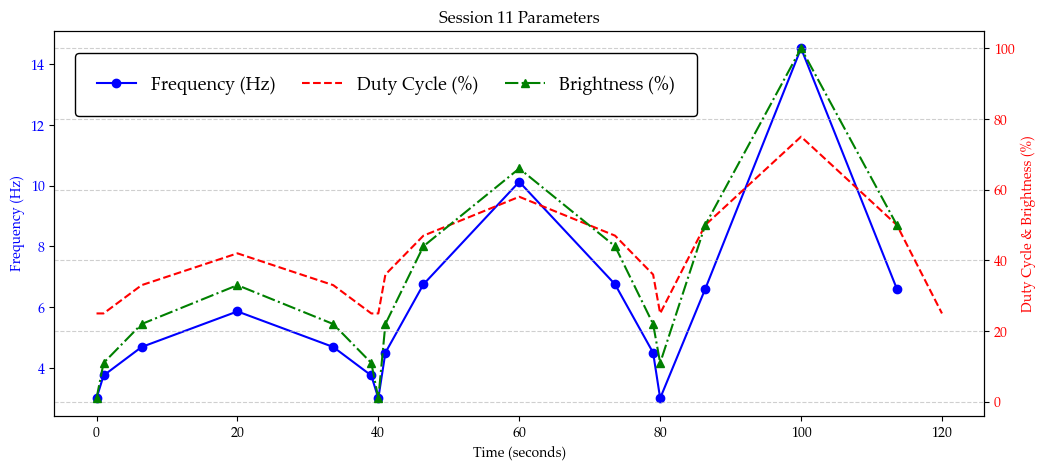

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define time points in seconds
time_points = [0.0, 1.0, 6.4, 20.0, 33.6, 39.0, 40.0, 41.0, 46.4, 60.0, 73.6, 79.0, 80.0, 86.4, 100.0, 113.6]

durations = [1, 5.4, 13.6, 13.6, 5.4, 1, 1, 5.4, 13.6, 13.6, 5.4, 1, 6.4, 13.6, 13.6, 6.4]

# Normalized frequencies
frequencies = [3, 3.75, 4.688, 5.859, 4.688, 3.75, 3, 4.5, 6.75, 10.125, 6.75, 4.5, 3, 6.6, 14.52, 6.6]

# Duty cycle values explicitly mapped to durations
duty_cycle_ranges = [
    (0.25, 0.25), (0.25, 0.33), (0.33, 0.42), (0.42, 0.33), (0.33, 0.25), (0.25, 0.25),
    (0.25, 0.36), (0.36, 0.47), (0.47, 0.58), (0.58, 0.47), (0.47, 0.36), (0.36, 0.25),
    (0.25, 0.5), (0.5, 0.75), (0.75, 0.5), (0.5, 0.25)
]

def interpolate_duty_cycle(duty_ranges, durations):
    duty_cycle = []
    time_mapped = []
    current_time = 0

    for (start, end), duration in zip(duty_ranges, durations):
        steps = int(duration * 10)
        interpolated_values = np.linspace(start, end, steps)
        duty_cycle.extend(interpolated_values)
        time_mapped.extend(np.linspace(current_time, current_time + duration, steps))
        current_time += duration

    return time_mapped, duty_cycle

# Generate mapped duty cycle
time_duty_cycle, duty_cycle = interpolate_duty_cycle(duty_cycle_ranges, durations)

# Brightness values
brightness = [
    1, 11, 22, 33, 22, 11, 1, 22,
    44, 66, 44, 22, 11, 50, 100, 50
]

fig, ax1 = plt.subplots(figsize=(12, 5))

# Frequency plot
ax1.plot(time_points, frequencies, marker='o', linestyle='-', color='b', label='Frequency (Hz)')
ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("Frequency (Hz)", color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Duty Cycle and Brightness on second y-axis
ax2 = ax1.twinx()
ax2.plot(time_duty_cycle, np.array(duty_cycle) * 100, linestyle='--', color='r', label='Duty Cycle (%)')
ax2.plot(time_points[:len(brightness)], brightness, marker='^', linestyle='-.', color='g', label='Brightness (%)')
ax2.set_ylabel("Duty Cycle & Brightness (%)", color='r')
ax2.tick_params(axis='y', labelcolor='r')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper left",
    bbox_to_anchor=(0.0125, 0.965),
    ncol=3,
    fontsize=13,        # bigger legend text
    borderpad=1.2,      # more space inside box
    labelspacing=0.9,   # more vertical space between entries
    handlelength=2.2,   # longer line samples
    handletextpad=0.8,  # space between symbol and text
    columnspacing=1.5,  # space between columns
    frameon=True,
    framealpha=1,       # fully opaque
    facecolor="white",  # solid background
    edgecolor="black"   # box outline
)

plt.title("Session 11 Parameters")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()